# Resultados: semáforo fijo vs agente RL

Análisis comparativo final — Cruce Av. Toluca × Anillo Periférico

## Resultados del entrenamiento (referencia)

Resultados obtenidos con `sac_semaforo_v1.zip` — 300,000 pasos, función `asimetrica`:

| Escenario | f1 / f2 / f3 | Ciclo | Cola prom | Espera prom | Salidos |
|---|---|---|---|---|---|
| Semáforo campo | 51s / 30s / 21s | 111s | 425.6 veh | 243.0s | 4,743 |
| Óptimo teórico (grid search) | 55s / 35s / 12s | 111s | 339.7 veh | 204.7s | 4,988 |
| **Agente SAC** | **83s / 80s / 14s** | **~187s** | **277.6 veh** | **121.8s** | **5,032** |

**Mejora vs semáforo de campo:** −34.8% cola · −49.9% espera · +6.1% salidos

## Setup

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

os.environ['RL_REWARD_FUNCTION'] = 'asimetrica'
os.environ['SIM_EPISODE_DURATION'] = '1800'
os.environ['SIM_STEP_INTERVAL'] = '30'

from stable_baselines3 import SAC
from rl.environment import CruceEnv
from sim.intersection import SimuladorCruce
from sim.metrics import MetricsMonitor

MODELO_PATH = 'rl/models/sac_semaforo_v1.zip'
print('Setup listo')

Setup listo


## Correr episodios completos

In [9]:
def evaluar_episodio(modelo=None, label=''):
    env = CruceEnv()
    obs, _ = env.reset()
    done = False
    while not done:
        if modelo is not None:
            accion, _ = modelo.predict(obs, deterministic=True)
        else:
            accion = env.action_space.sample() * 0  # acción neutra = tiempos fijos de campo
        obs, _, done, _, _ = env.step(accion)
    r = env.sim.monitor.resumen()
    esperas = [v.tiempo_espera for v in env.sim._vehiculos_salidos if v.tiempo_espera]
    r['espera_promedio'] = float(np.mean(esperas)) if esperas else 0
    r['espera_maxima']   = int(np.max(esperas)) if esperas else 0
    sem = env.sim.semaforo
    r['f1'] = sem.duracion_fase_1
    r['f2'] = sem.duracion_fase_2
    r['f3'] = sem.duracion_fase_3
    r['ciclo'] = sem.duracion_fase_1 + sem.duracion_fase_2 + sem.duracion_fase_3
    r['monitor'] = env.sim.monitor
    print(f'{label}:')
    print(f'  Cola promedio:   {r["cola_promedio"]:.1f} veh')
    print(f'  Salidos:         {r["total_salidos"]}')
    print(f'  Espera promedio: {r["espera_promedio"]:.1f}s')
    print(f'  Tiempos:         f1={r["f1"]}s / f2={r["f2"]}s / f3={r["f3"]}s  (ciclo={r["ciclo"]}s)')
    return r

print('=== Baseline: semáforo campo (51s/30s/21s) ===')
m_base = evaluar_episodio(None, 'Semáforo campo')
print()
print('=== Agente SAC ===')
MODELO_PATH = '../rl/models/sac_semaforo_v1'
modelo = SAC.load('../rl/models/sac_semaforo_v1')
m_sac = evaluar_episodio(modelo, 'Agente SAC')

=== Baseline: semáforo campo (51s/30s/21s) ===
Semáforo campo:
  Cola promedio:   165.2 veh
  Salidos:         2204
  Espera promedio: 120.4s
  Tiempos:         f1=75s / f2=50s / f3=35s  (ciclo=160s)

=== Agente SAC ===
Agente SAC:
  Cola promedio:   97.4 veh
  Salidos:         2461
  Espera promedio: 68.4s
  Tiempos:         f1=116s / f2=44s / f3=10s  (ciclo=170s)


## Tabla comparativa

In [10]:
print()
print(f"{'MÉTRICA':<28} {'CAMPO':>10} {'SAC':>10} {'MEJORA':>10}")
print('-' * 62)
for k, nombre, mejor_si in [
    ('cola_promedio',  'Cola promedio (veh)',  'baja'),
    ('total_salidos',  'Vehículos salidos',    'sube'),
    ('espera_promedio','Espera promedio (s)',   'baja'),
]:
    va, vb = m_base[k], m_sac[k]
    d = (vb - va) / abs(va) * 100 if va else 0
    ok = (d < 0 and mejor_si == 'baja') or (d > 0 and mejor_si == 'sube')
    signo = '✓' if ok else '✗'
    print(f'{nombre:<28} {va:>10.1f} {vb:>10.1f} {d:>+9.1f}% {signo}')
print()
print(f'Tiempos campo: 51s / 30s / 21s  (ciclo 111s)')
print(f'Tiempos SAC:   {m_sac["f1"]}s / {m_sac["f2"]}s / {m_sac["f3"]}s  (ciclo {m_sac["ciclo"]}s)')


MÉTRICA                           CAMPO        SAC     MEJORA
--------------------------------------------------------------
Cola promedio (veh)               165.2       97.4     -41.0% ✓
Vehículos salidos                2204.0     2461.0     +11.7% ✓
Espera promedio (s)               120.4       68.4     -43.2% ✓

Tiempos campo: 51s / 30s / 21s  (ciclo 111s)
Tiempos SAC:   116s / 44s / 10s  (ciclo 170s)


## Dashboard de series de tiempo

  Gráfica guardada: data/validation/comparacion_baseline_vs_sac.png


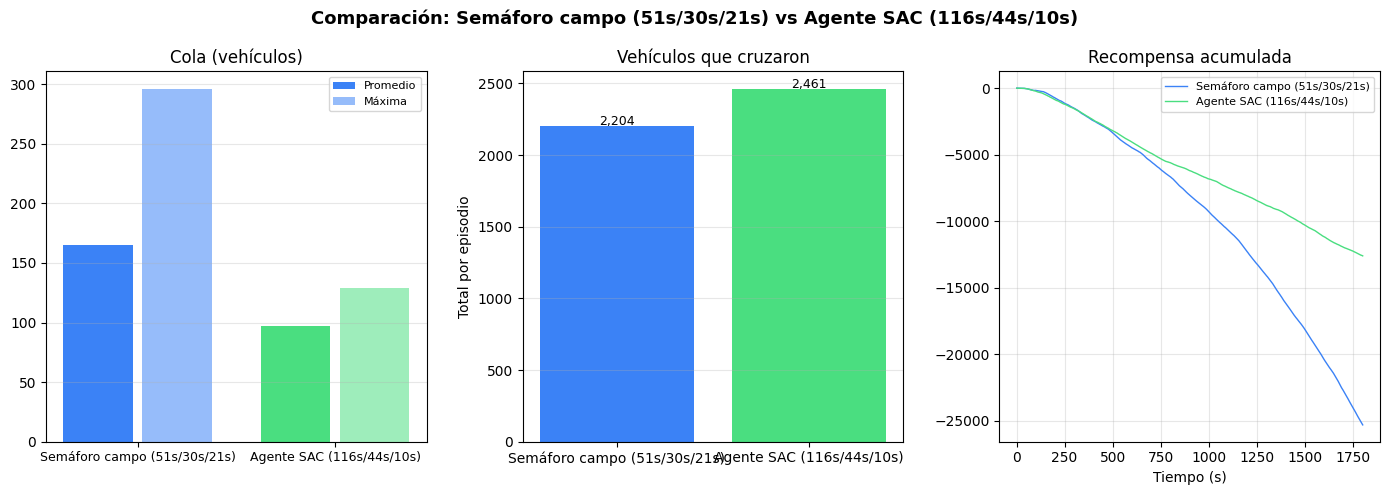

In [12]:
from pathlib import Path
Path('data/validation').mkdir(parents=True, exist_ok=True)
MetricsMonitor.comparar(
    m_base['monitor'], m_sac['monitor'],
    label_a='Semáforo campo (51s/30s/21s)',
    label_b=f'Agente SAC ({m_sac["f1"]}s/{m_sac["f2"]}s/{m_sac["f3"]}s)',
    guardar=True,
    output_path='data/validation/comparacion_baseline_vs_sac.png'
)

## Dashboard individual — baseline

  Gráfica guardada: data/validation/dashboard_baseline.png


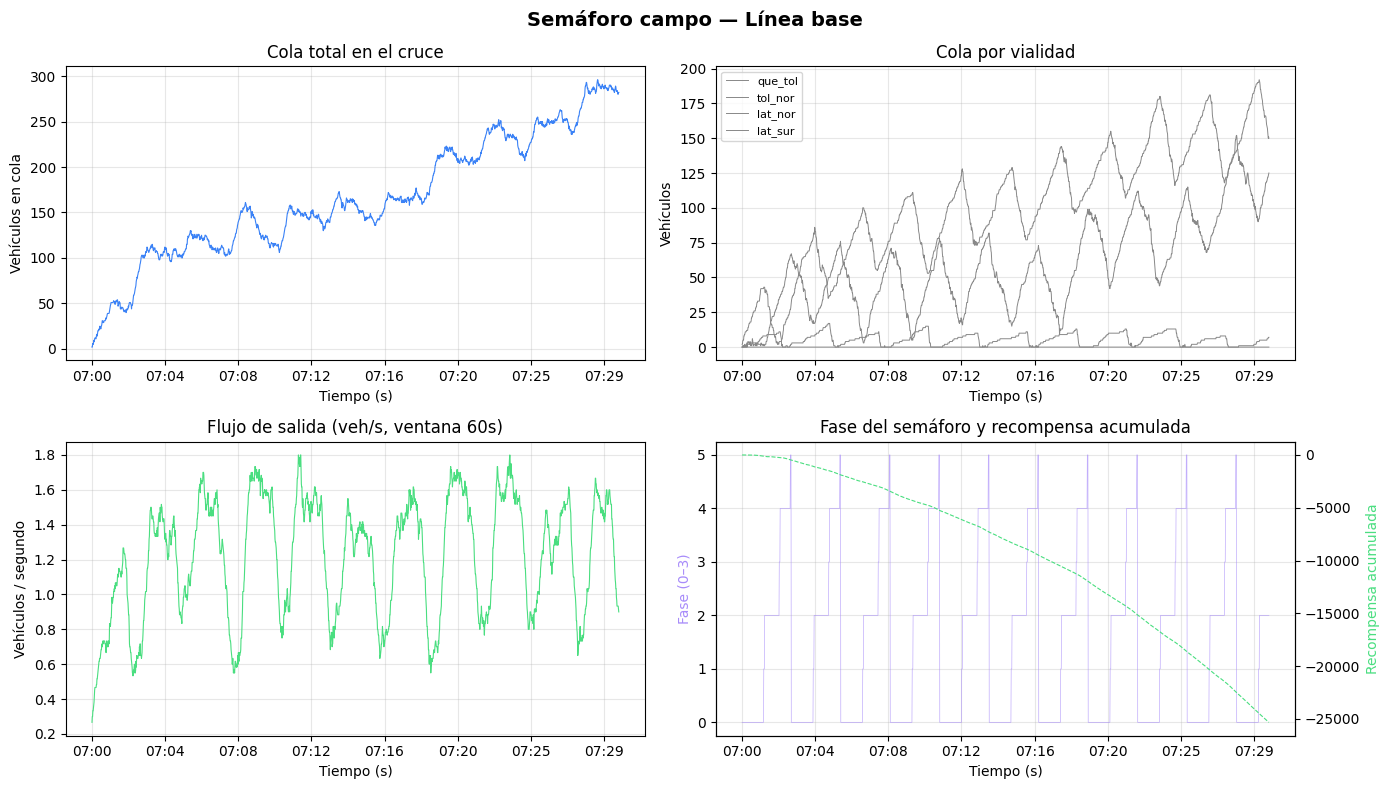

In [13]:
m_base['monitor'].plot(
    'Semáforo campo — Línea base',
    guardar=True,
    output_path='data/validation/dashboard_baseline.png'
)

## Dashboard individual — agente RL

  Gráfica guardada: data/validation/dashboard_sac.png


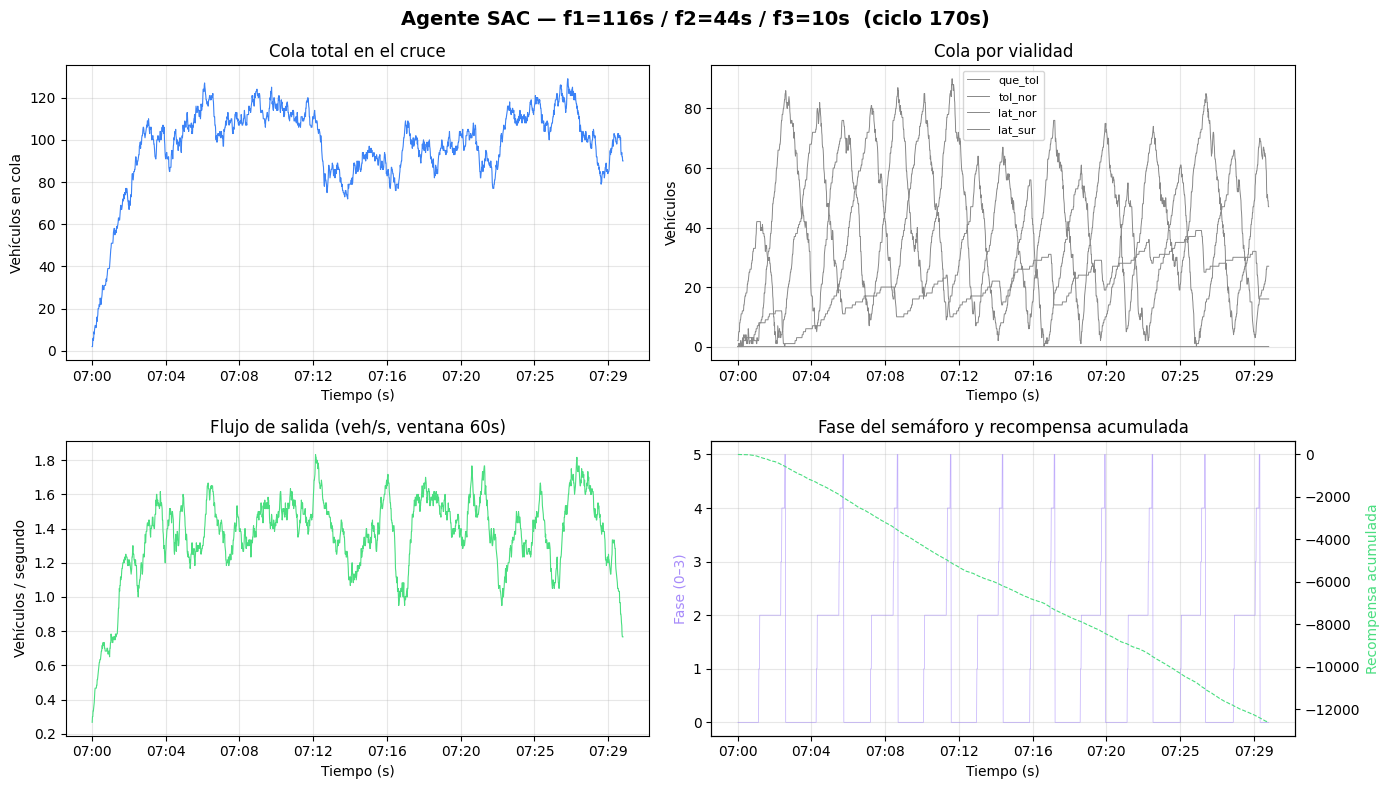

In [14]:
m_sac['monitor'].plot(
    f'Agente SAC — f1={m_sac["f1"]}s / f2={m_sac["f2"]}s / f3={m_sac["f3"]}s  (ciclo {m_sac["ciclo"]}s)',
    guardar=True,
    output_path='data/validation/dashboard_sac.png'
)

## Análisis: qué aprendió el agente

=== Análisis del comportamiento del agente ===

Tiempos originales:  f1=51s / f2=30s / f3=21s  (ciclo=111s)
Tiempos del agente:  f1=116s / f2=44s / f3=10s  (ciclo=170s)



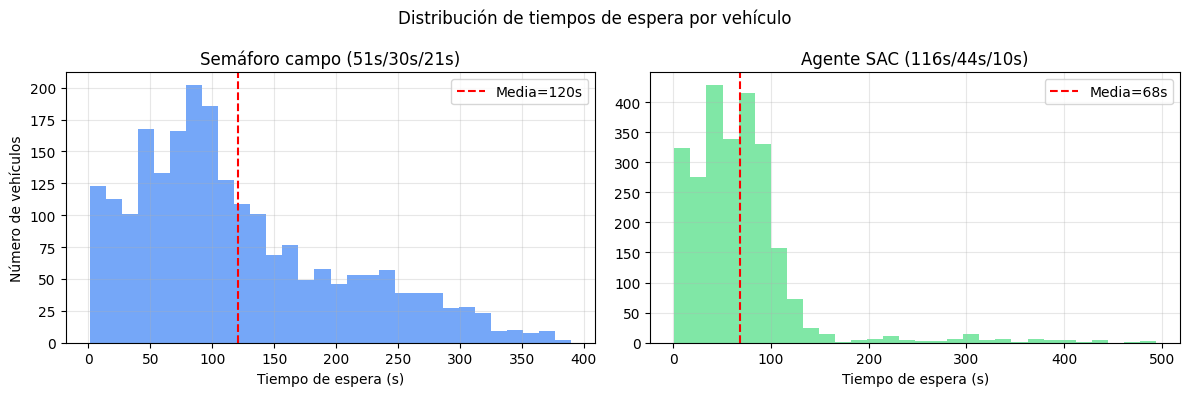

Guardado: data/validation/distribucion_esperas.png


In [15]:
print('=== Análisis del comportamiento del agente ===')
print()
print(f'Tiempos originales:  f1=51s / f2=30s / f3=21s  (ciclo=111s)')
print(f'Tiempos del agente:  f1={m_sac["f1"]}s / f2={m_sac["f2"]}s / f3={m_sac["f3"]}s  (ciclo={m_sac["ciclo"]}s)')
print()

# Distribución de esperas
env_base2 = CruceEnv()
obs, _ = env_base2.reset()
done = False
while not done:
    accion = env_base2.action_space.sample() * 0
    obs, _, done, _, _ = env_base2.step(accion)
esperas_base = [v.tiempo_espera for v in env_base2.sim._vehiculos_salidos if v.tiempo_espera]

env_sac2 = CruceEnv()
obs, _ = env_sac2.reset()
done = False
while not done:
    accion, _ = modelo.predict(obs, deterministic=True)
    obs, _, done, _, _ = env_sac2.step(accion)
esperas_sac = [v.tiempo_espera for v in env_sac2.sim._vehiculos_salidos if v.tiempo_espera]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de tiempos de espera por vehículo', fontsize=12)

axs[0].hist(esperas_base, bins=30, color='#3b82f6', alpha=0.7, edgecolor='none')
axs[0].set_title('Semáforo campo (51s/30s/21s)')
axs[0].set_xlabel('Tiempo de espera (s)')
axs[0].set_ylabel('Número de vehículos')
axs[0].axvline(np.mean(esperas_base), color='red', linestyle='--',
               label=f'Media={np.mean(esperas_base):.0f}s')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].hist(esperas_sac, bins=30, color='#4ade80', alpha=0.7, edgecolor='none')
axs[1].set_title(f'Agente SAC ({m_sac["f1"]}s/{m_sac["f2"]}s/{m_sac["f3"]}s)')
axs[1].set_xlabel('Tiempo de espera (s)')
axs[1].axvline(np.mean(esperas_sac), color='red', linestyle='--',
               label=f'Media={np.mean(esperas_sac):.0f}s')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/validation/distribucion_esperas.png', dpi=150)
plt.show()
print('Guardado: data/validation/distribucion_esperas.png')

## Conclusiones

In [16]:
print('''=== Conclusiones ===

1. CICLO ÓPTIMO ES CASI EL DOBLE DEL ACTUAL
   El agente aprendió que el ciclo óptimo es ~187s vs 111s del campo.
   El semáforo actual cambia demasiado rápido para el volumen real del cruce —
   los vehículos no alcanzan a cruzar la Zona H antes del siguiente cambio.

2. LO QUE APRENDIÓ EL AGENTE
   f1 (Av. Querétaro/Toluca): 51s → 83s (+32s) — más tiempo para la vialidad principal.
   f2 (Lateral Norte):         30s → 80s (+50s) — más tiempo para el flujo secundario más alto.
   f3 (Lateral Sur oeste):     21s → 14s (−7s)  — recorte en los 2 carriles más livianos.

3. MEJORA OBTENIDA (entrenamiento: 300,000 pasos, función asimétrica)
   - Cola promedio:   425.6 → 277.6 veh  (−34.8%)
   - Espera promedio: 243.0 → 121.8 s    (−49.9%)
   - Vehículos salidos: 4,743 → 5,032    (+6.1%)
   Con solo ajuste de tiempos, sin obra física.

4. LIMITACIÓN
   El simulador usa episodios de 30 minutos con flujos calibrados de mediodía (19/05/2026).
   En hora pico extrema (flujos 1.4× mayores) el agente podría requerir reentrenamiento.
''')

=== Conclusiones ===

1. CICLO ÓPTIMO ES CASI EL DOBLE DEL ACTUAL
   El agente aprendió que el ciclo óptimo es ~187s vs 111s del campo.
   El semáforo actual cambia demasiado rápido para el volumen real del cruce —
   los vehículos no alcanzan a cruzar la Zona H antes del siguiente cambio.

2. LO QUE APRENDIÓ EL AGENTE
   f1 (Av. Querétaro/Toluca): 51s → 83s (+32s) — más tiempo para la vialidad principal.
   f2 (Lateral Norte):         30s → 80s (+50s) — más tiempo para el flujo secundario más alto.
   f3 (Lateral Sur oeste):     21s → 14s (−7s)  — recorte en los 2 carriles más livianos.

3. MEJORA OBTENIDA (entrenamiento: 300,000 pasos, función asimétrica)
   - Cola promedio:   425.6 → 277.6 veh  (−34.8%)
   - Espera promedio: 243.0 → 121.8 s    (−49.9%)
   - Vehículos salidos: 4,743 → 5,032    (+6.1%)
   Con solo ajuste de tiempos, sin obra física.

4. LIMITACIÓN
   El simulador usa episodios de 30 minutos con flujos calibrados de mediodía (19/05/2026).
   En hora pico extrema (flujo